# EDA - Using matched treatment and control groups only

## Check calendar matching (matching result is not that good)

In [ ]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
%run ./consumption_plot

In [ ]:
%run ./peak_plot

In [ ]:
%run ./consumption_cohort

## Load Data 

### Adopt matching result

In [ ]:
# Change here !!!
match_method = "calendar"

# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2

In [6]:
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching/{match_method}/matches")
print(matches.head())

treated_ids = matches["treated_id"].unique()
control_ids = matches["control_id"].unique()
print(f"Treated IDs: {len(treated_ids)}, Control IDs: {len(control_ids)}")

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 8, Finished, Available, Finished, False)

           treated_id          control_id adoption_month  distance  valid_dim  \
0  735999166200137406  735999166300952831     2025-10-01  0.031445          2   
1  735999166200137406  735999166300967484     2025-10-01  0.121341          1   
2  735999166200137406  735999166300970620     2025-10-01  0.127231          1   
3  735999166200137406  735999166200590676     2025-10-01  0.130646          7   
4  735999166200137406  735999166200494745     2025-10-01  0.168624          7   

   match_rank  
0           1  
1           2  
2           3  
3           4  
4           5  
Treated IDs: 1695, Control IDs: 3195


### Consumption data

In [7]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
print(month_result.shape)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 9, Finished, Available, Finished, False)

(4538578, 17)


In [8]:
# Consumption data
month_result["treatment"] = None
month_result.loc[month_result["aID"].isin(treated_ids), "treatment"] = 1
month_result.loc[month_result["aID"].isin(control_ids), "treatment"] = 0
month_result = month_result[month_result["treatment"].notna()]
print(month_result.shape)
month_result.head()

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 10, Finished, Available, Finished, False)

(450687, 18)


,aID,TIDPUNKT,price,tariff_active,peak1_time,peak1_consumption,peak2_time,peak2_consumption,peak3_time,peak3_consumption,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group,treatment
93,735999166200086049,2024-02-01,all,0,2024-02-16 15:00:00,3.26200000,2024-02-23 14:00:00,2.50200000,2024-02-26 13:00:00,2.50000000,2.754667,0.123704,0.450242816092,NaT,None,12509.66700000,low,0
94,735999166200086049,2024-03-01,high,0,2024-03-26 14:00:00,3.36200000,2024-03-08 14:00:00,3.00300000,2024-03-18 12:00:00,2.92600000,3.097000,0.412807,0.689107692308,NaT,None,12509.66700000,low,0
95,735999166200086049,2023-03-01,low,0,2023-03-09 05:00:00,2.60000000,2023-03-11 09:00:00,2.20000000,2023-03-12 13:00:00,1.60000000,2.133333,0.054289,0.329438202247,NaT,None,12509.66700000,low,0
96,735999166200086049,2025-07-01,low,0,2025-07-22 13:00:00,3.71700000,2025-07-15 13:00:00,3.31900000,2025-07-27 13:00:00,3.18100000,3.405667,0.215826,0.440266129032,NaT,None,12509.66700000,low,0
97,735999166200086049,2023-09-01,low,0,2023-09-01 16:00:00,2.10200000,2023-09-12 14:00:00,1.94800000,2023-09-23 15:00:00,1.88600000,1.978667,0.079557,0.385641666667,NaT,None,12509.66700000,low,0


## Electricity data

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 11, Finished, Available, Finished, True)

Before: 184134
After: 135840
Before: 450687
After: 332622


<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

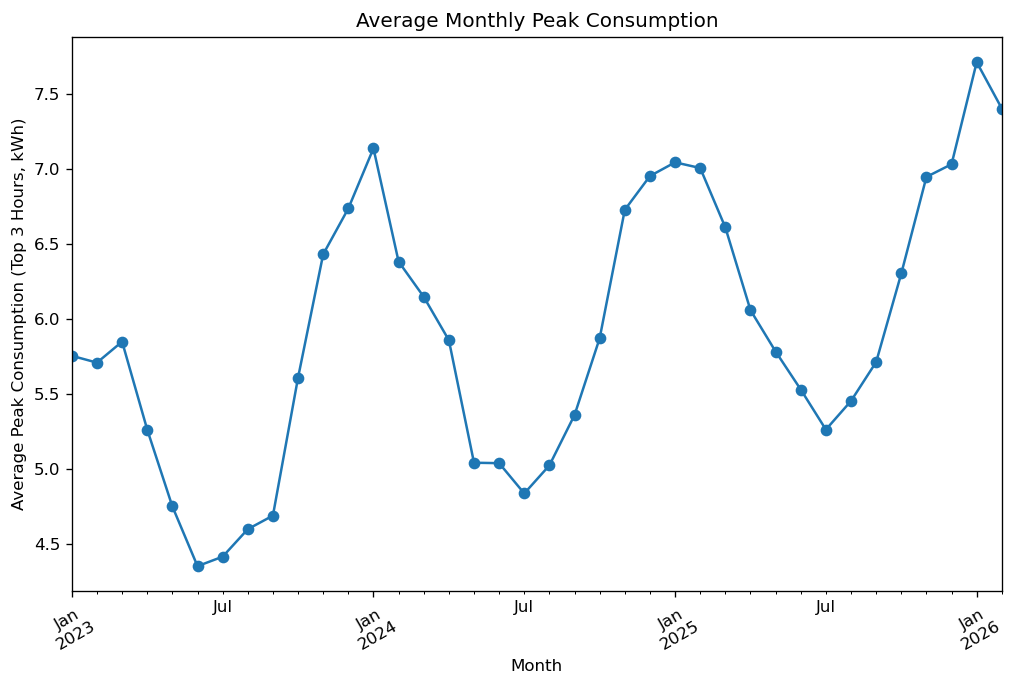

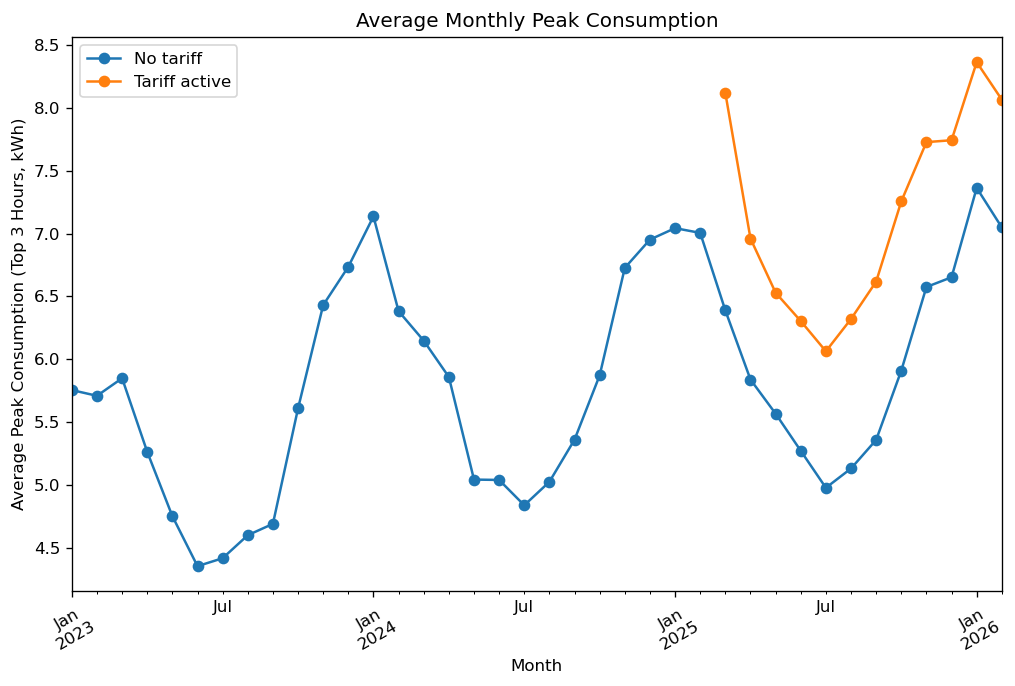

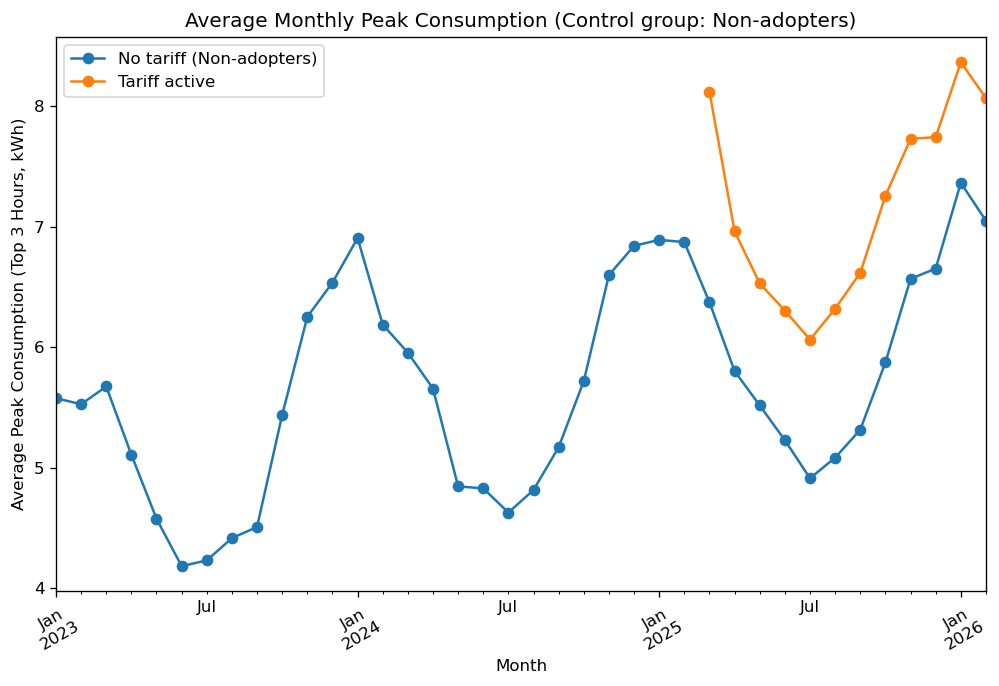

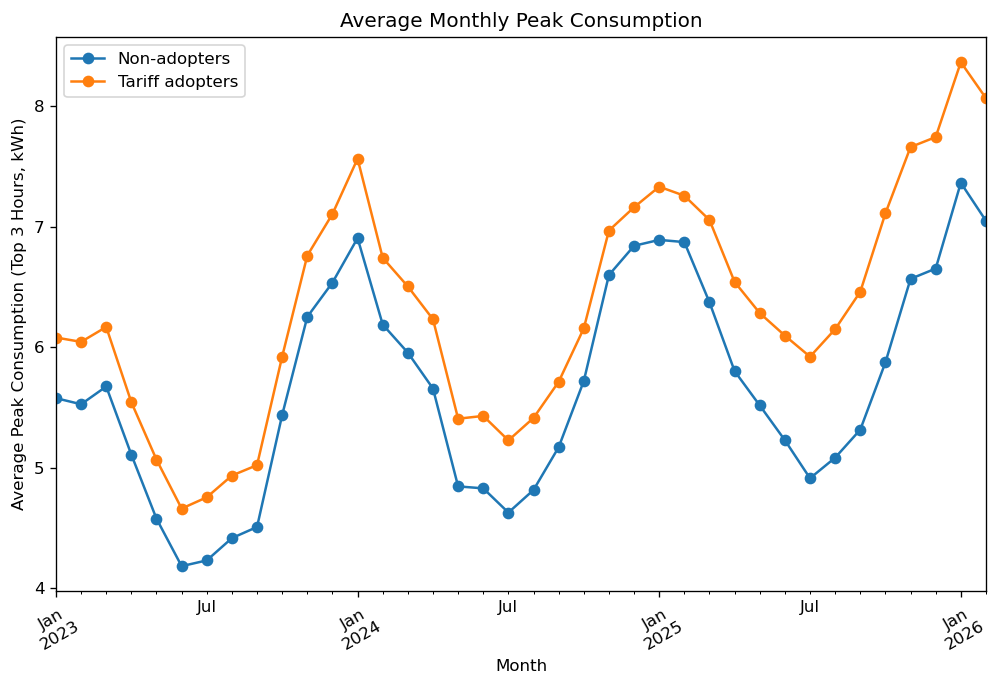

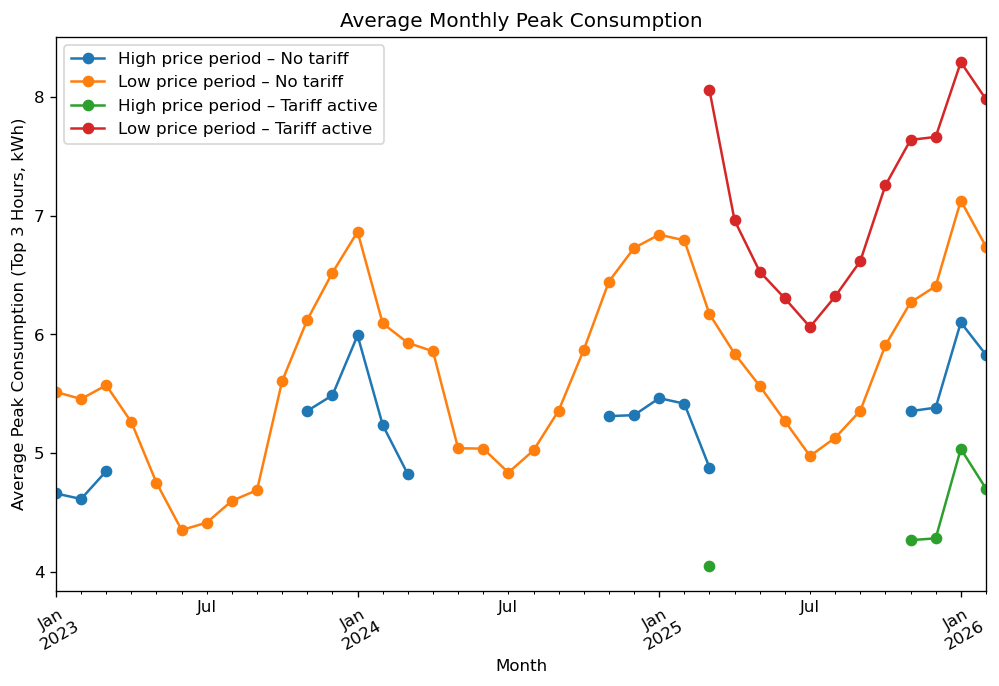

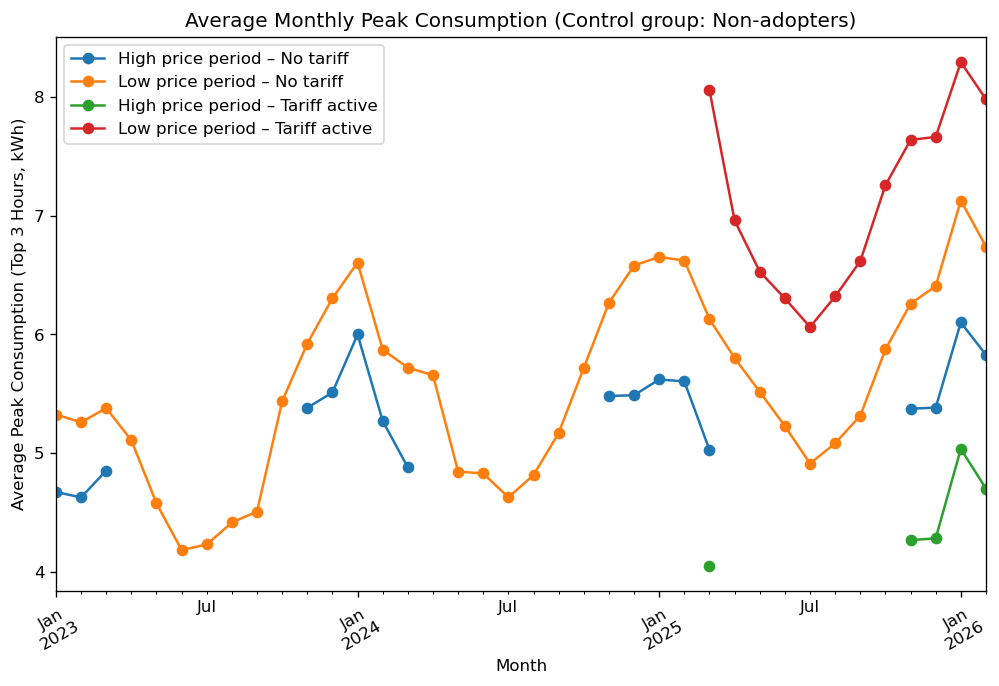

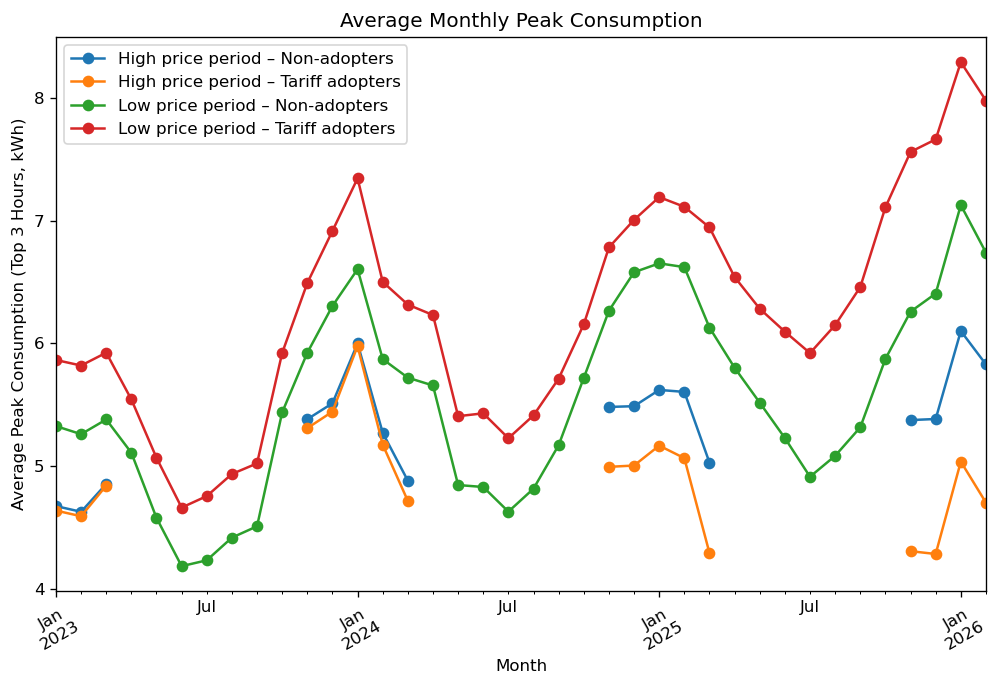

In [9]:
# month
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

plot_tariff_adoption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption"
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

plot_tariff_adoption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    by_price=True
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 12, Finished, Available, Finished, True)

array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

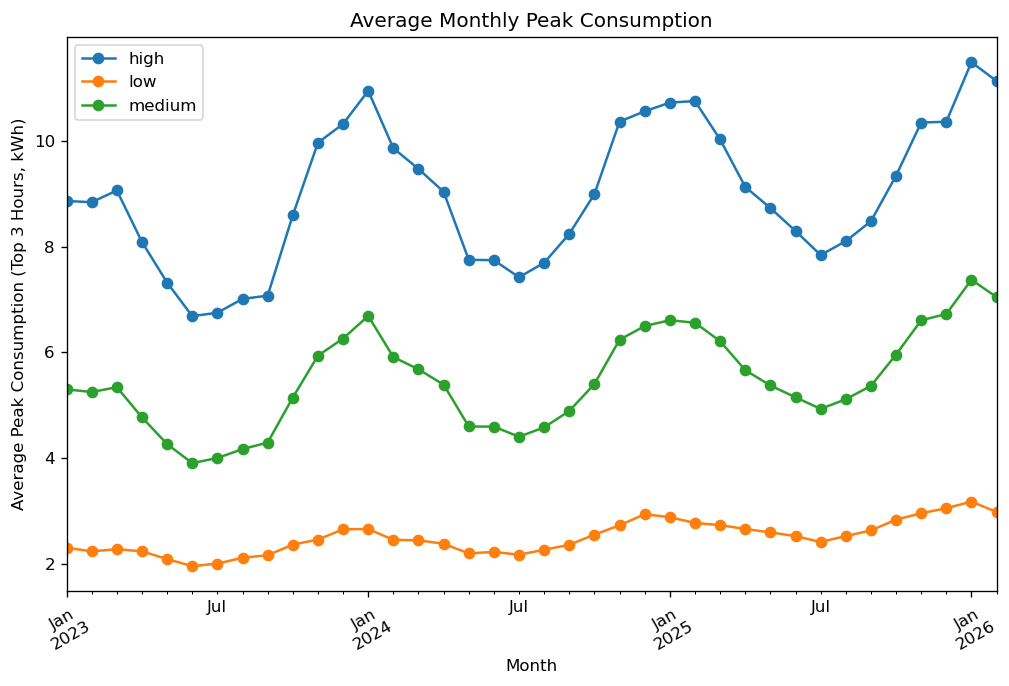

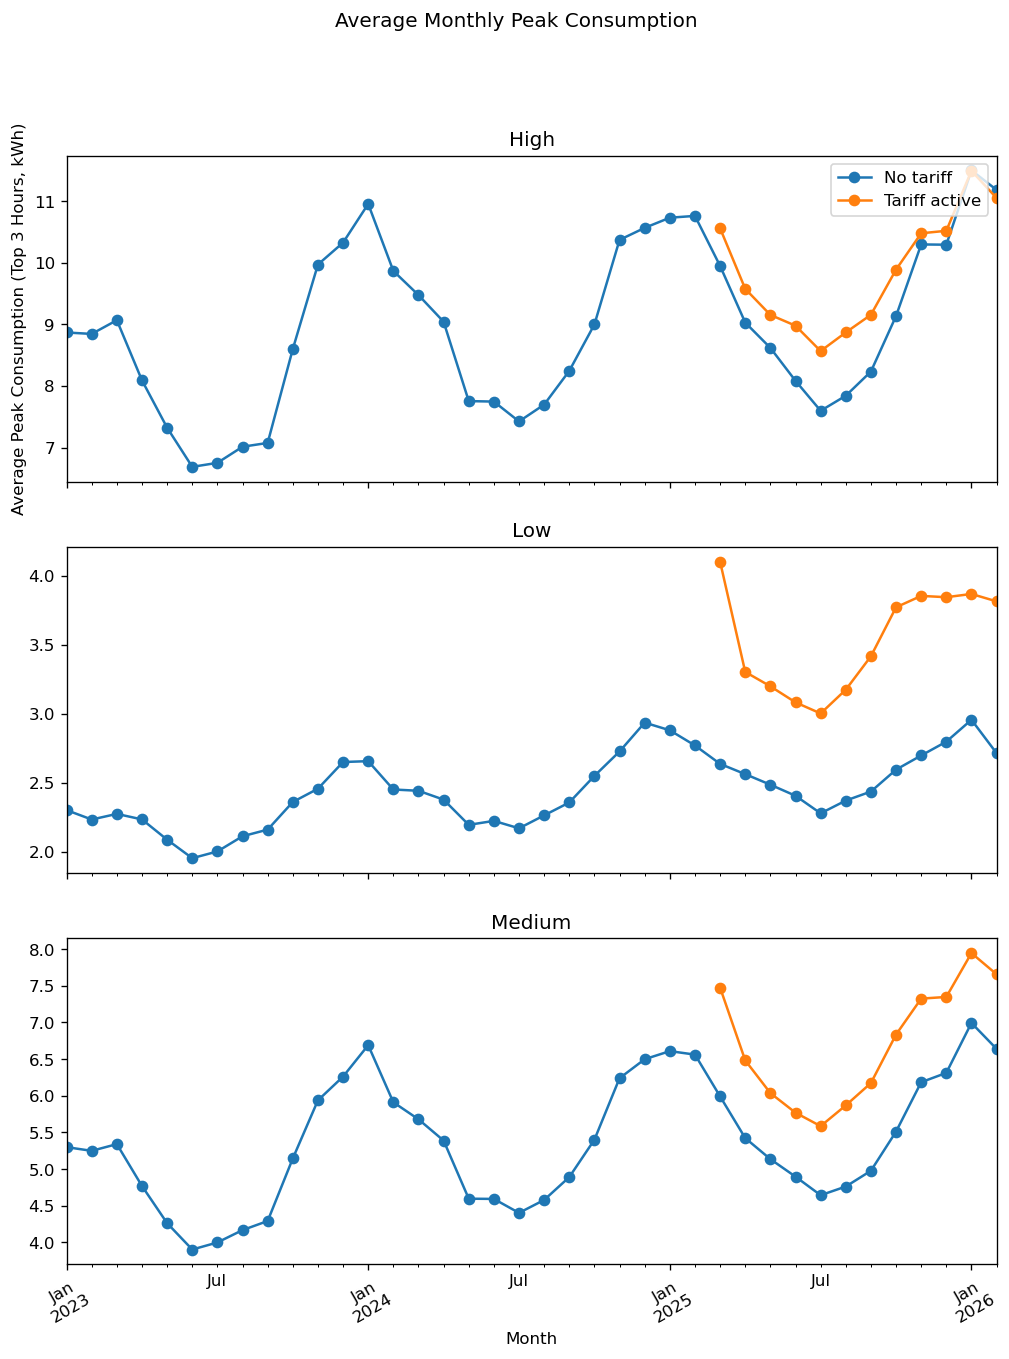

In [10]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 13, Finished, Available, Finished, True)

Before: 184134
After: 135840


array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

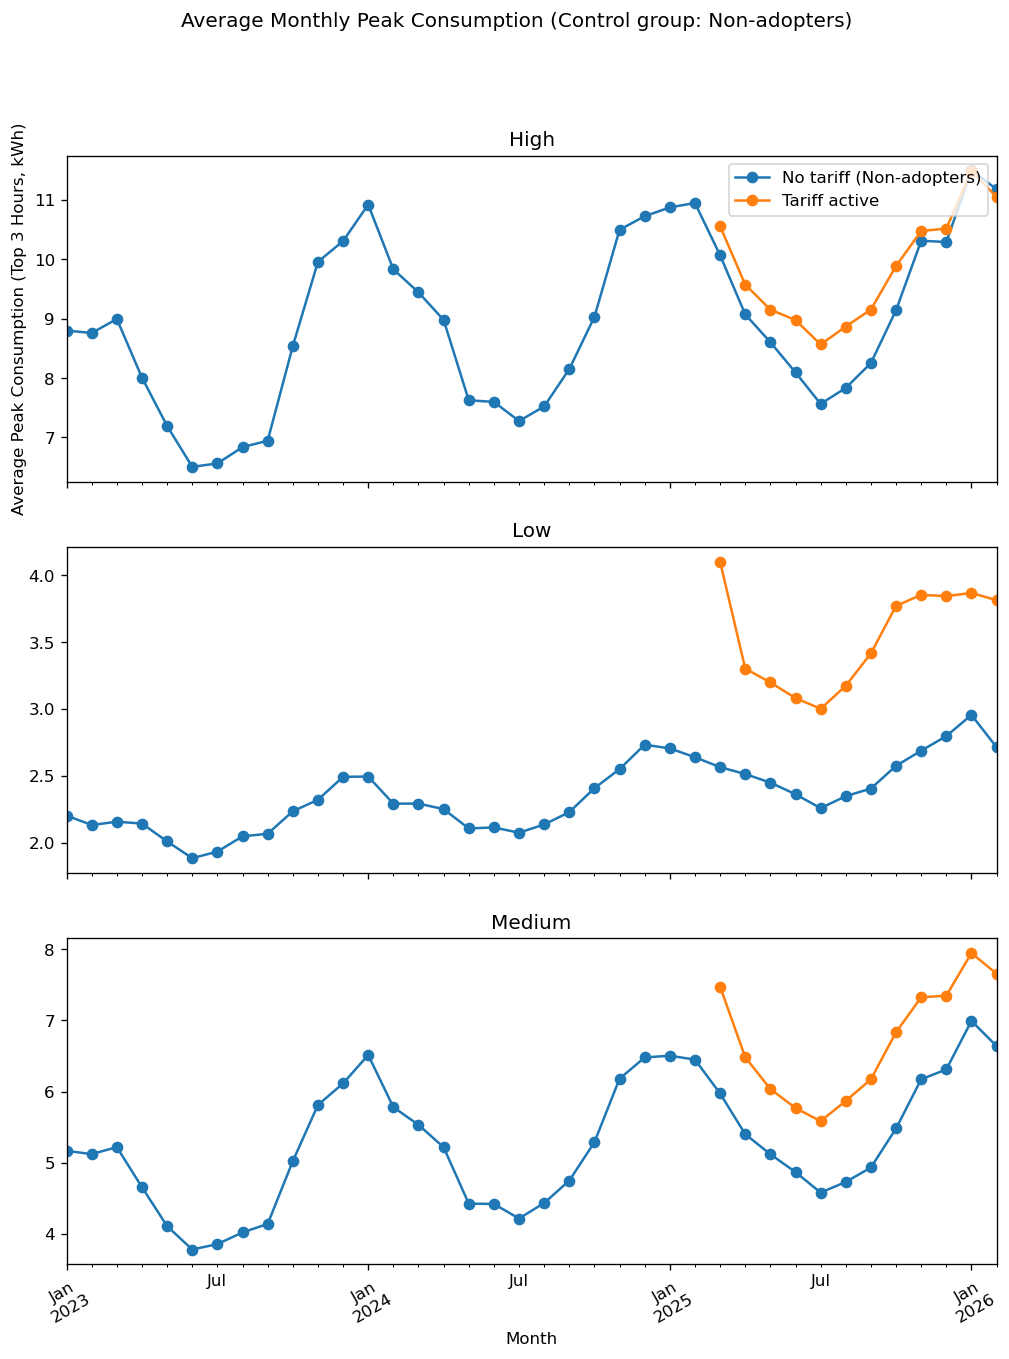

In [11]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 14, Finished, Available, Finished, True)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

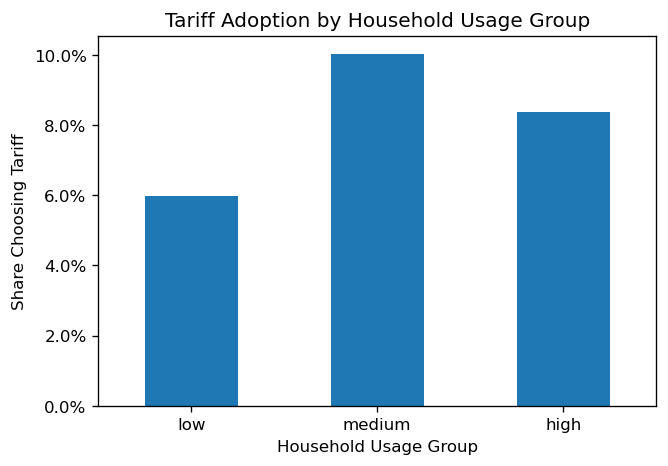

In [12]:
plot_tariff_adoption_by_usage(
    month_result[month_result["price"] == "all"],
    figsize=(6, 4)
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 15, Finished, Available, Finished, True)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

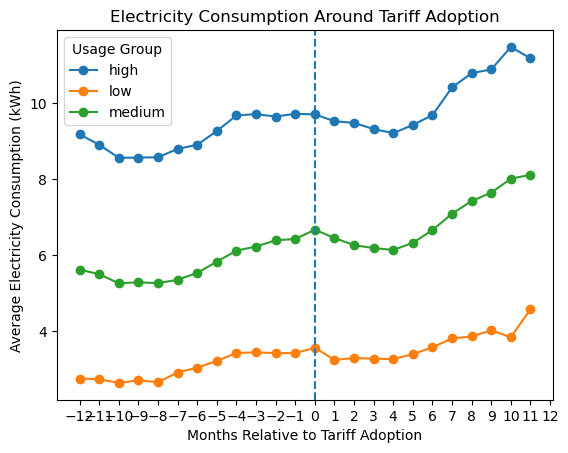

In [13]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 16, Finished, Available, Finished, True)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

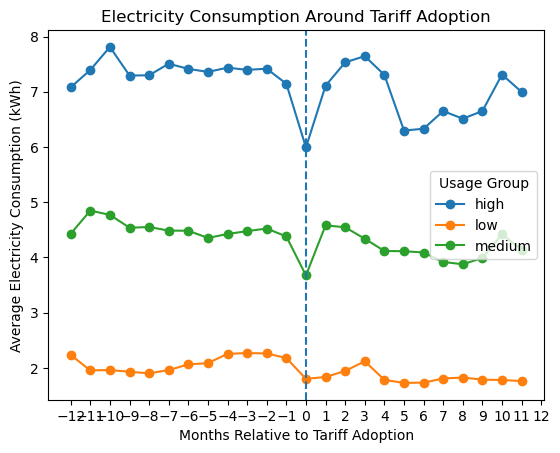

In [14]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 17, Finished, Available, Finished, True)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

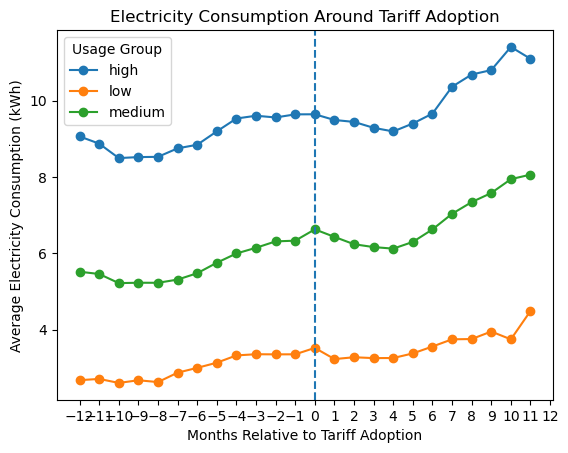

In [15]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 18, Finished, Available, Finished, True)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

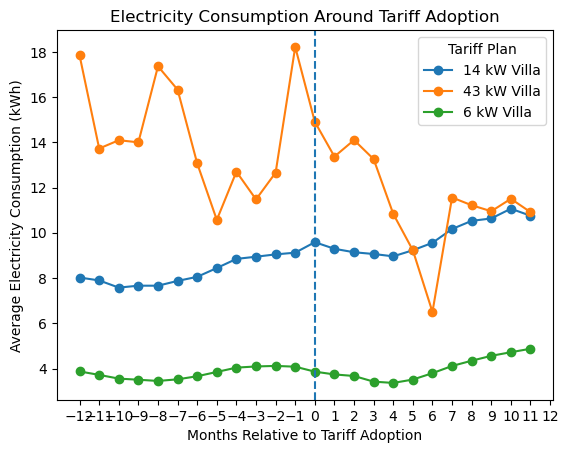

In [16]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 19, Finished, Available, Finished, True)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

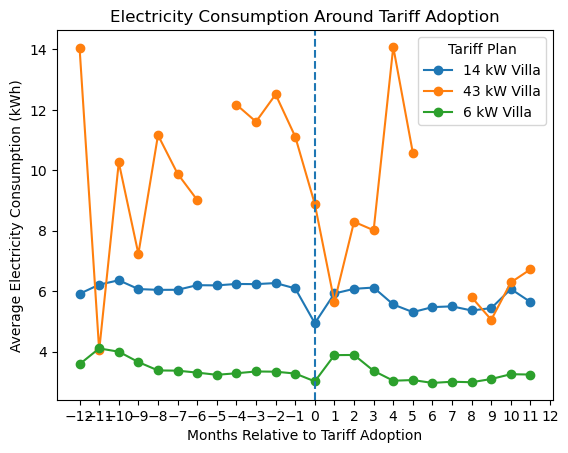

In [17]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

In [18]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, ee2bbf3e-e904-45cd-b1f6-a21bbfba4b63, 20, Submitted, Running, Running, True)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

In [ ]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)


StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
# Overall peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"], 
    price_label="all"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
# Low peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


StatementMeta(, , -1, Waiting, , Waiting, True)

## Look at specific month

In [ ]:
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-03"
# )
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-04"
# )

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-03", "2025-04", ]
)

plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-08", "2025-09", "2025-10"]
)

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
plot_cohort_panels(
    month_result[month_result["price"] == "all"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2
)

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
plot_cohort_panels(
    month_result[month_result["price"] == "high"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2
)

StatementMeta(, , -1, Waiting, , Waiting, True)

In [ ]:
plot_cohort_panels(
    month_result[month_result["price"] == "low"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2
)

StatementMeta(, , -1, Waiting, , Waiting, True)